# **Using pretrained ViT-MAE deep learning model (no finetuning)**

In [1]:
# Import Libraries

from pathlib import Path

import numpy as np
import pandas as pd
import anndata as ad
import torch

from torch.utils.data import DataLoader
from torchvision import transforms

from transformers import ViTMAEForPreTraining

from scportrait.tools.ml.datasets import H5ScSingleCellDataset

from vit_mae_training_inference.utils import feature_extractor

In [2]:
# Configuration
DATA_PATH = Path(
    "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_cropped_project/extraction/data/single_cells.h5sc"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

BATCH_SIZE = 16 #for 20 cells, used batch size 4

In [3]:
# Image transformations (resize according to ViT-MAE input size, convert to 3 channels (as it takes a 3-channel input), and apply feature extractor))
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.Lambda(
        lambda x: x.repeat(3,1,1)
    ),

    feature_extractor
])

In [4]:
# Load the dataset
dataset = H5ScSingleCellDataset(
    dir_list=[DATA_PATH],
    dir_labels=[0],
    select_channel=[1],      # DAPI only (known from previous notebook)
    transform=transform,
    return_id=True,
)

Total single cell records: 4063


In [5]:
#subset = torch.utils.data.Subset(dataset, range(20))
loader = DataLoader(dataset, #pass 'subset' argument to DataLoader if you want to use a subset of the dataset
                    batch_size=BATCH_SIZE,
                    shuffle=False, # Set to False for inference
                    num_workers=4,
                    pin_memory=True,
                    )


In [6]:
# Load the pretrained ViT-MAE model
model = ViTMAEForPreTraining.from_pretrained(
    "facebook/vit-mae-base"
)

model.to(DEVICE)

model.eval() # Set the model to evaluation mode

Loading weights:   0%|          | 0/334 [00:00<?, ?it/s]

ViTMAEForPreTraining(
  (vit): ViTMAEModel(
    (embeddings): ViTMAEEmbeddings(
      (patch_embeddings): ViTMAEPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
    )
    (layers): ModuleList(
      (0-11): 12 x ViTMAELayer(
        (attention): ViTMAEAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMAEMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=76

In [7]:
# Disable masking
model.config.mask_ratio = 0.0

In [8]:
# Register forward hook (to extract intermediate layer outputs)
layer_outputs = {}

def get_intermediate(module, input, output):
    layer_outputs["encoder_layernorm"] = output

handle = model.vit.layernorm.register_forward_hook(
    get_intermediate
)

In [9]:
# Run inference
cls_embeddings = []

pooled_embeddings = []

labels = []

cell_ids = []

with torch.no_grad():

    for imgs, lbls, ids in loader:

        imgs = imgs.to(DEVICE)

        model(imgs)

        out = layer_outputs["encoder_layernorm"]

        cls = out[:, :1, :]

        pooled = torch.mean(
            out[:,1:,:],
            dim=1
        )

        cls_embeddings.append(
            cls.cpu().numpy()
        )

        pooled_embeddings.append(
            pooled.cpu().numpy()
        )

        labels.append(
            np.array(lbls)
        )

        cell_ids.append(
            np.array(ids)
        )

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [10]:
# Check the shape of the embeddings
print("CLS:", len(cls_embeddings))

print("Patch:", len(pooled_embeddings))

CLS: 254
Patch: 254


In [11]:
print(type(cls_embeddings))
print(type(cls_embeddings[0]))
print(cls_embeddings[0].shape)

print(type(pooled_embeddings))
print(type(pooled_embeddings[0]))
print(pooled_embeddings[0].shape)

<class 'list'>
<class 'numpy.ndarray'>
(16, 1, 768)
<class 'list'>
<class 'numpy.ndarray'>
(16, 768)


In [12]:
cls_embeddings = np.concatenate(cls_embeddings, axis=0)
pooled_embeddings = np.concatenate(pooled_embeddings, axis=0)

labels = np.concatenate(labels, axis=0)
cell_ids = np.concatenate(cell_ids, axis=0)

In [13]:
print(type(cls_embeddings))
print(cls_embeddings.shape)

print(type(pooled_embeddings))
print(pooled_embeddings.shape)

print(labels.shape)
print(cell_ids.shape)

<class 'numpy.ndarray'>
(4063, 1, 768)
<class 'numpy.ndarray'>
(4063, 768)
(4063,)
(4063,)


In [14]:
assert pooled_embeddings.shape[0] == len(labels) == len(cell_ids)

In [15]:
# Build Anndata
adata = ad.AnnData(X=pooled_embeddings)

adata.obs["label"] = labels
adata.obs["cell_id"] = cell_ids

print(adata)

AnnData object with n_obs × n_vars = 4063 × 768
    obs: 'label', 'cell_id'


In [16]:
print(adata.obs.head())

   label  cell_id
0    0.0        1
1    0.0        2
2    0.0        3
3    0.0        4
4    0.0        5


In [17]:
print(adata.var.head())

Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [18]:
print(adata.X.shape)
print(adata.X)

(4063, 768)
[[-0.1484024   0.0362905   0.17112254 ... -0.3110482  -0.24380551
   0.3321449 ]
 [-0.14417247  0.02702047  0.12397511 ... -0.2963218  -0.26733232
   0.2759785 ]
 [-0.0992133   0.05590327  0.20331198 ... -0.34360227 -0.24532291
   0.27910975]
 ...
 [-0.19779712 -0.05185857  0.11351829 ... -0.27493462 -0.24640909
   0.26597825]
 [-0.15463887 -0.05273874  0.1168641  ... -0.2356357  -0.23754202
   0.2564523 ]
 [-0.21001549 -0.08714981  0.09829433 ... -0.29216072 -0.22561696
   0.30594507]]


In [19]:
print(np.isnan(adata.X).sum())
print(np.isinf(adata.X).sum())

0
0


In [20]:
print(adata.X.min())
print(adata.X.max())
print(adata.X.mean())
print(adata.X.std())

-4.7414675
4.345837
-0.0053976043
0.32922462


In [21]:
import numpy as np

print(np.allclose(adata.X[0], adata.X[1]))
print(np.linalg.norm(adata.X[0] - adata.X[1]))

False
2.2676017


In [22]:
import scanpy as sc

sc.pp.pca(adata)

print(adata.obsm["X_pca"].shape)

(4063, 50)


In [23]:
sc.pp.neighbors(
    adata,
    use_rep="X"
)

In [24]:
sc.tl.umap(adata)

print(adata.obsm["X_umap"])

[[ 0.43774047 -0.22007918]
 [ 1.1345417   0.19690481]
 [ 0.35803196 -0.24696712]
 ...
 [12.405857    4.472788  ]
 [11.0545225   3.0968468 ]
 [16.540985    2.2549505 ]]


In [25]:
sc.tl.leiden(
    adata,
    resolution=0.5
)

print(adata.obs)

/tmp/ipykernel_777702/1018391756.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(


      label  cell_id leiden
0       0.0        1      3
1       0.0        2      3
2       0.0        3      3
3       0.0        4      3
4       0.0        5      3
...     ...      ...    ...
4058    0.0     4604      2
4059    0.0     4605      2
4060    0.0     4606      1
4061    0.0     4607      0
4062    0.0     4608      1

[4063 rows x 3 columns]


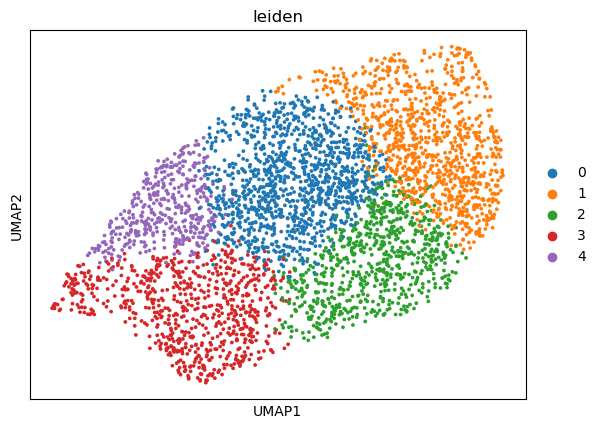

In [26]:
sc.pl.umap(
    adata,
    color="leiden"
)

In [27]:
# Add the anndata to existing SpatialData

from spatialdata import SpatialData

output_path = "../data/results/xenium_dapi_cellfeaturizer.sdata.zarr"

# Open the existing SpatialData
sdata = SpatialData.read(output_path)

# Add the new table in memory
sdata.tables[
    "ViT-MAE_pretrained_PooledEmbeddings"
] = adata

# Verify that the new table has been added to the SpatialData object before writing to disk
print(sdata.tables.keys())

dict_keys(['CellFeaturizer_nucleus', 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus', 'ViT-MAE_pretrained_PooledEmbeddings'])


In [28]:
# Write only the new table to disk
sdata.write_element(
    "ViT-MAE_pretrained_PooledEmbeddings",
    overwrite=True,
)

/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWarning: zarr v3 autosharding will be the default in the next minor release.
  return next(self.gen)
/scratch/tmurugan/conda_envs/env_scportrait/lib/python3.11/contextlib.py:137: UserWar